Importing Libraries

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix

2026-03-23 07:51:14.652368: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774252274.856005      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774252274.907845      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774252275.342034      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774252275.342073      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774252275.342076      55 computation_placer.cc:177] computation placer alr

Importing Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/asdasdasasdas/garbage-classification


Setting path to the dataset directory with classes of waste images

In [3]:
DATASET_PATH = "/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification"

Creating train, validation and test from the dataset and also appying normalization and augmentation to the images

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_data = test_gen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Found 2527 images belonging to 6 classes.


In [5]:
print(train_data.class_indices)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


Custom CNN Model

In [6]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1774252303.791798      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1774252308.371041     145 service.cc:152] XLA service 0x7de8c00060b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774252308.371077     145 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774252308.762099     145 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/64 ━━━━━━━━━━━━━━━━━━━━ 6:46 6s/step - accuracy: 0.3438 - loss: 1.7628

I0000 00:00:1774252312.696667     145 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 728ms/step - accuracy: 0.2499 - loss: 2.6534 - val_accuracy: 0.3638 - val_loss: 1.5516
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 444ms/step - accuracy: 0.4354 - loss: 1.3547 - val_accuracy: 0.3817 - val_loss: 1.5034
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 29s 448ms/step - accuracy: 0.5185 - loss: 1.2574 - val_accuracy: 0.4453 - val_loss: 1.4317
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 439ms/step - accuracy: 0.5667 - loss: 1.1584 - val_accuracy: 0.4871 - val_loss: 1.4028
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 435ms/step - accuracy: 0.5799 - loss: 1.0826 - val_accuracy: 0.4791 - val_loss: 1.3124
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 29s 459ms/step - accuracy: 0.6092 - loss: 0.9908 - val_accuracy: 0.4871 - val_loss: 1.2854
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 493ms/step - accuracy: 0.6549 - loss: 0.9305 - val_accuracy: 0.5149 - val_loss: 1.2432
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 515ms/step - accuracy: 0.6642 - loss: 0.9280 - val_accuracy: 0.489

Transfer Learning using MobileNetV2 trained on imageNet

In [7]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(train_data.num_classes, activation='softmax')(x)

mobilenet_model = tf.keras.Model(inputs=base_model.input, outputs=output)

mobilenet_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

mobile_history = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 736ms/step - accuracy: 0.5801 - loss: 1.1292 - val_accuracy: 0.7316 - val_loss: 0.7452
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 507ms/step - accuracy: 0.8252 - loss: 0.4813 - val_accuracy: 0.7316 - val_loss: 0.6891
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 505ms/step - accuracy: 0.8628 - loss: 0.3689 - val_accuracy: 0.7296 - val_loss: 0.7376
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 513ms/step - accuracy: 0.8993 - loss: 0.2784 - val_accuracy: 0.7535 - val_loss: 0.6806
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 523ms/step - accuracy: 0.9097 - loss: 0.2512 - val_accuracy: 0.7575 - val_loss: 0.6952
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 29s 457ms/step - accuracy: 0.9270 - loss: 0.2379 - val_accuracy: 0.7594 - val_loss: 0.7016
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 483ms/step - accuracy: 0.9408 - loss: 0.1799 - val_accuracy: 0.7435 - val_loss: 0.7027
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 463ms/

Evaluation

In [8]:
y_true = test_data.classes
y_pred = np.argmax(mobilenet_model.predict(test_data), axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 168ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96       403
           1       0.94      0.86      0.90       501
           2       0.88      0.98      0.92       410
           3       0.96      0.98      0.97       594
           4       0.91      0.92      0.92       482
           5       0.90      0.90      0.90       137

    accuracy                           0.93      2527
   macro avg       0.93      0.93      0.93      2527
weighted avg       0.93      0.93      0.93      2527

Confusion Matrix:
[[377   0   4  14   1   7]
 [  1 431  35   2  31   1]
 [  0   4 401   2   3   0]
 [  4   2   2 580   1   5]
 [  0  18  14   4 445   1]
 [  0   2   2   3   7 123]]


Visualing Custom CNN model vs pretrained MobileNetV2

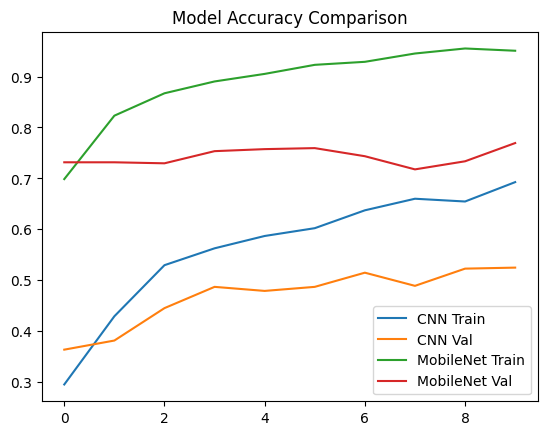

In [9]:
plt.figure()
plt.plot(cnn_history.history['accuracy'], label='CNN Train')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val')
plt.plot(mobile_history.history['accuracy'], label='MobileNet Train')
plt.plot(mobile_history.history['val_accuracy'], label='MobileNet Val')
plt.legend()
plt.title("Model Accuracy Comparison")
plt.show()

Saving model

In [10]:
cnn_model.save("/kaggle/working/cnn_model.h5")
mobilenet_model.save("/kaggle/working/mobilenet_model.h5")